**生成式AI的使用**：对于本作业，生成式AI的使用需遵守有关合作的相同政策。就像与其他合作者一样，每个学生必须独立于交互输出写下解决方案，并且提交的材料应包含说明合作性质的注释。使用生成式AI工具来大幅完成作业的各个部分不符合本作业的精神，并将违反[荣誉代码(Honor Code)](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。


In [1]:
# 这会将您的 Google Drive 挂载到 Colab 虚拟机。
#from google.colab import drive
#drive.mount('/content/drive')

# TODO: 输入您保存在 Drive 中解压后的作业文件夹名称
# 例如：'cs231n/assignments/assignment3/'
#FOLDERNAME = "cs231n/assignments/assignment3/"
#assert FOLDERNAME is not None, "[!] Enter the foldername."

# 既然我们已经挂载了您的 Drive，这能确保
# Colab 虚拟机的 Python 解释器可以从中加载
# python 文件。
#import sys
#sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# # 这会将 Emoji 数据集下载到您的 Drive
# # 如果它还不存在的话。
# %cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
# !bash get_datasets.sh
# %cd /content/drive/My\ Drive/$FOLDERNAME

# 去噪扩散概率模型 (Denoising Diffusion Probabilistic Models, DDPM)

到目前为止，我们已经探索了判别模型，这些模型被训练用来产生带有标签的输出。从简单的图像分类到句子生成，这些问题在很大程度上仍然被框定为分类问题（带有词汇空间中的标签以及捕获多词标签的循环机制）。现在，我们将扩展我们的技术储备，构建一个能够生成与给定训练图像集相似的新图像的生成模型。

生成模型有很多种类型，包括生成对抗网络 (GANs)、自回归模型、标准化流模型和变分自编码器 (VAEs)，它们都能合成引人注目的图像。然而，在2020年，Ho 等人通过将扩散概率模型与去噪分数匹配相结合，引入了去噪扩散概率模型 (DDPMs)。这产生了一个生成模型，它既易于训练，又强大到足以生成复杂的高质量图像。以下提供了 DDPMs 的高层次概述。有关更多详细信息，请参阅课程幻灯片和 DDPM 原始论文 [1]。


# 前向过程 (Forward Process)
假设 $q(x_0)$ 是干净数据集图像的分布。我们将前向加噪过程定义为一个包含微小加噪步骤的马尔可夫链：

$$q(x_t | x_{t-1}) \sim N(x_t; \sqrt{1-\beta_t} x_{t-1} , \beta_t I)$$

其中逐步方差 $(\beta_1, ..., \beta_T)$ 决定了噪声调度 (noise schedule)。由于高斯分布的性质，我们可以将 $q(x_t | x_0)$ 表示为闭合形式：

$$q(x_t | x_0) \sim N(x_t; \sqrt{\bar{\alpha}_t} x_0 , (1-\bar{\alpha}_t) I)$$

其中 $\alpha_t = 1-\beta_t$ 且 $\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s$。
如果噪声调度 $(\beta_1, ..., \beta_T)$ 设置得当，最终分布 $q(x_T)$ 将变得与纯高斯噪声 $N(0, I)$ 无法区分。

回想一下，从高斯分布 $x \sim N(\mu, \sigma^2)$ 中采样等同于计算 $\sigma * \epsilon + \mu$，其中 $\epsilon \sim N(0, 1)$。因此，给定 $x_{t-1}$ 或 $x_0$，从 $q(x_t | x_{t-1})$ 或 $q(x_t | x_0)$ 中采样是直截了当的。正因为如此，前向过程非常简单，不需要学习。

# 逆向过程 (Reverse Process)
逆向过程通过多个步骤从纯噪声 $x_T$ 重建干净的图像 $x_0$。设 $p(x_{t-1} | x_t)$ 表示 $q(x_t | x_{t-1})$ 的逆向步骤。
第一个关键见解是，学习反转每个单独的去噪步骤比一次性反转整个前向过程更容易。换句话说，对每个 $t$ 学习 $p(x_{t-1} | x_t)$ 比直接学习 $p(x_0 | x_T)$ 更容易。

然而，学习 $p(x_{t-1} | x_t)$ 仍然具有挑战性。尽管 $q(x_t | x_{t-1})$ 是高斯分布，但 $p(x_{t-1} | x_t)$ 可能呈现任何复杂的形式，并且几乎可以肯定不是高斯分布。从任意分布中建模和采样，比处理像高斯分布这样简单的参数化分布要困难得多。

第二个关键见解是，如果前向过程中的逐步噪声 $\beta_t$ 足够小，那么逆向步骤 $p(x_{t-1} | x_t)$ 也接近于高斯分布。因此，我们只需要估计它的均值和方差。在实践中，将 $p(x_{t-1} | x_t)$ 的方差设置为匹配 $\beta_t$（与前向步骤相同）效果很好。因此，学习逆向过程可以简化为学习均值 $\mu(x_t, t; \theta)$，其中 $\theta$ 表示神经网络的参数。

# 去噪目标 (Denoising Objective)
生成模型的优化是通过最小化数据集样本的预期负对数似然 $\mathbb{E}[-\log{p_\theta(x_0)}]$ 来实现的。每个样本的似然可以表示为：$p_\theta(x_0) = p(x_T)\prod_{t=1}^T p(x_{t-1} | x_t)$。由于在许多情况下这个目标是难以处理的，各种类别的生成模型通常优化负对数似然的变分下界。

Ho 等人证明了这个目标等同于最小化以下去噪损失：

$$\mathbb{E}_{t, x_0, \epsilon}\left[ \| \epsilon - \epsilon_\theta (\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon, t ) \|^2 \right]$$

其中 $t$ 在 1 到 T 之间均匀分布，$x_0$ 是干净样本，$\epsilon$ 从标准高斯分布 $N(0, I)$ 中采样，$\epsilon_\theta$ 是一个神经网络模型，被训练来从输入的带噪样本 $x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$ 中预测噪声 $\epsilon$。换句话说，$\epsilon_\theta$ 学习对输入的带噪图像进行去噪。请注意，这等同于预测干净样本，因为可以根据方程 $x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$ 从带噪图像和干净样本中恢复出噪声。


[1] Denoising Diffusion Probabilistic Models. Jonathan Ho, Ajay Jain, Pieter Abbeel. [链接](https://arxiv.org/pdf/2006.11239)



# 在本 Notebook 中...
我们将实现并训练一个 DDPM 模型，以生成基于文本提示的小型 32 x 32 表情符号 (emoji) 图像。首先，我们将根据论文 [1] 的公式 (4) 实现前向加噪过程。然后，我们将构建一个 UNet 模型，它将 $x_t$ 和 $t$ 作为输入（可选地带有诸如文本提示之类的其他条件），并输出与 $x_t$ 形状相同的张量。最后，我们将实现去噪目标并训练我们的 DDPM 模型。

我们使用预训练 CLIP [2] 模型中的文本编码器将输入文本编码为 512 维向量。为了加速训练，我们已经预先编码了训练集中的文本数据。

[2] Learning transferable visual models from natural language supervision. Radford et. al. [链接](https://github.com/openai/CLIP)

In [2]:
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to C:\Users\95265\AppData\Local\Temp\pip-req-build-hq7_q1r3
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\95265\AppData\Local\Temp\pip-req-build-hq7_q1r3'

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import torchvision.utils as tv_utils
from cs231n.emoji_dataset import EmojiDataset
from cs231n.gaussian_diffusion import GaussianDiffusion

def rel_error(x, y):
    """返回相对误差。"""
    return np.max(np.abs(x - y) / (np.maximum(1e-10, np.abs(x) + np.abs(y))))


In [4]:
# 首先，让我们加载并可视化数据集。
# 数据集中的每个样本都是一个元组：(image, {"text_emb": <tensor>, "text": <string>})
# 我们将使用预训练的文本编码器将文本编码为嵌入向量 (embedding vector)。
# 我们已经将数据集文本预先编码为嵌入，以加快训练速度。
image_size = 32
dataset = EmojiDataset(image_size)


emoji_data.npz already downloaded.
text_embeddings.pt already downloaded.


One sample: (image: [3, 32, 32], { "text_emb": [512], "text": string })


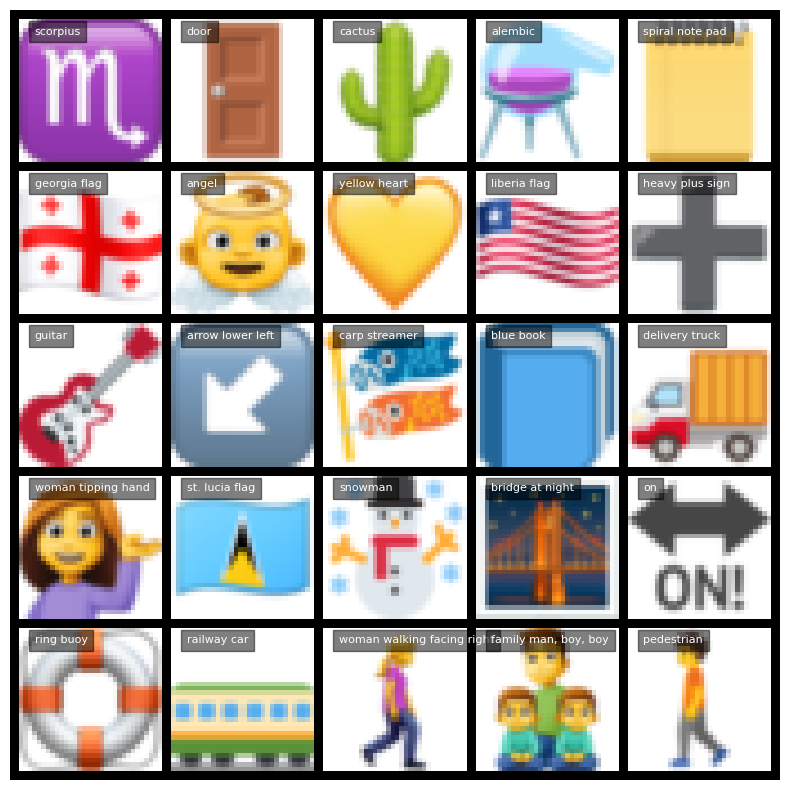

In [5]:
def visualize_samples(dataset, num_samples=25, grid_size=(5, 5)):
    # 随机采样索引
    indices = random.sample(range(len(dataset)), num_samples)
    samples = [dataset[i] for i in indices]

    # 检查一个样本
    img_shape = list(samples[0][0].shape)
    emb_shape = list(samples[0][1]["text_emb"].shape)
    print(f"One sample: (image: {img_shape}, {{ \"text_emb\": {emb_shape}, \"text\": string }})")

    # 提取图像和文本
    images = torch.stack([sample[0] for sample in samples])  # 堆叠图像
    texts = [sample[1]["text"] for sample in samples]  # 提取文本描述

    # 创建图像网格
    grid_img = tv_utils.make_grid(images, nrow=grid_size[1], padding=2)

    # 转换为 numpy 格式以便绘图
    grid_img = grid_img.permute(1, 2, 0).numpy()

    # 绘制图像
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(grid_img)
    ax.axis("off")

    # 添加文本注释
    grid_w, grid_h = grid_size
    img_w, img_h = grid_img.shape[1] // grid_w, grid_img.shape[0] // grid_h

    for i, text in enumerate(texts):
        row, col = divmod(i, grid_w)
        x, y = col * img_w, row * img_h
        ax.text(x+5, y+5, text[:30], fontsize=8, color='white', bbox=dict(facecolor='black', alpha=0.5))

    plt.show()

visualize_samples(dataset)

## q_sample

现在我们将定义前向加噪过程。请通读 `cs231n/gaussian_diffusion.py` 中的 GaussianDiffusion 类。查阅原始 DDPM 论文 [1] 以获取公式。实现 `q_sample` 方法并在下面进行测试。您应该会看到相对误差为零。

In [6]:
# 测试 GaussianDiffusion.q_sample 方法
sz = 2
b = 3

diffusion = GaussianDiffusion(
      model=None,
      image_size=sz,
      timesteps=1000,
      beta_schedule="sigmoid",
)

t = torch.tensor([0, 300, 999]).long()
x_start = torch.linspace(-0.9, 0.6, b*3*sz*sz).view(b, 3, sz, sz)
noise = torch.linspace(-0.7, 0.8, b*3*sz*sz).view(b, 3, sz, sz)
x_t = diffusion.q_sample(x_start, t, noise)

expected_x_t = np.array([
    [
        [[-0.9119949, -0.86840147], [-0.8248081, -0.7812148]],
        [[-0.7376214, -0.694028], [-0.65043473, -0.6068413]],
        [[-0.563248, -0.51965463], [-0.47606122, -0.43246788]],
    ],
    [
        [[-0.42800453, -0.37039882], [-0.31279305, -0.2551873]],
        [[-0.19758154, -0.1399758], [-0.08237009, -0.024764337]],
        [[0.032841414, 0.090447165], [0.14805292, 0.20565866]],
    ],
    [
        [[0.32864183, 0.37152246], [0.41440308, 0.45728368]],
        [[0.50016433, 0.5430449], [0.5859255, 0.6288062]],
        [[0.67168677, 0.7145674], [0.757448, 0.8003287]],
    ],
]).astype(np.float32)

# 应该看到相对误差为零
print("x_t error: ", rel_error(x_t.numpy(), expected_x_t))

x_t error:  5.104469e-07


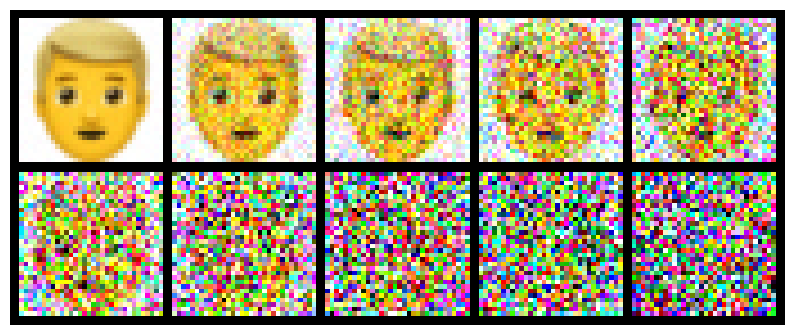

In [7]:
# 让我们可视化各个时间步下的带噪图像。
diffusion = GaussianDiffusion(
      model=None,
      image_size=image_size,
      timesteps=1000,
)

B = 10
img = dataset[770][0]  # 3 x H x W
x_start = img[None].repeat(B, 1, 1, 1)  # B x 3 x H x W
noise = torch.randn_like(x_start)  # B x 3 x H x W
t = torch.linspace(0, 1000-1, B).long()

x_start = diffusion.normalize(x_start)
x_t = diffusion.q_sample(x_start, t, noise)
x_t = diffusion.unnormalize(x_t).clamp(0, 1)
grid_img = tv_utils.make_grid(x_t, nrow=5, padding=2)
grid_img = grid_img.permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(grid_img)
ax.axis("off")
plt.show()

扩散模型可以被训练来预测干净的图像或噪声，因为其中一个可以从另一个中推导出来（在上面的“去噪目标”部分中已解释）。实现 `predict_start_from_noise` 和 `predict_noise_from_start` 方法并在下面进行测试。您应该会看到相对误差小于 1e-5。

In [8]:
# 测试 `predict_noise_from_start` 和 `predict_start_from_noise`
sz = 2
b = 3

diffusion = GaussianDiffusion(
      model=None,
      image_size=sz,
      timesteps=1000,
      beta_schedule="sigmoid",
)

t = torch.tensor([1, 300, 998]).long()
x_start = torch.linspace(-0.91, 0.67, b*3*sz*sz).view(b, 3, sz, sz)
noise = torch.linspace(-0.73, 0.81, b*3*sz*sz).view(b, 3, sz, sz)
x_t = diffusion.q_sample(x_start, t, noise)

pred_noise = diffusion.predict_noise_from_start(x_t, t, x_start)
pred_x_start = diffusion.predict_start_from_noise(x_t, t, noise)

# 相对误差应在 1e-5 左右或更小
print("noise error: ", rel_error(pred_noise.numpy(), noise.numpy()))
print("x_start error: ", rel_error(pred_x_start.numpy(), x_start.numpy()))

noise error:  1.0600407e-06
x_start error:  1.8902663e-06


## UNet 模型

既然我们已经定义了前向过程，让我们定义用于对输入图像进行去噪的 UNet 模型。UNet 是一种为图像到图像任务（如分割、风格迁移等）设计的神经网络架构。它由一个编码器（或下采样模块）组成，该模块将输入图像转换为具有递减空间分辨率和递增特征维度的分层特征。解码器（或上采样模块）随后通过逐步恢复空间分辨率来上采样特征，其结构与编码器镜像对称。在每个解码器层中，来自相应编码器层的特征被拼接在一起，为细节提供了直接通路。这种方法减轻了瓶颈层的负担，使它们能够专注于捕捉高级表征，而不是记忆微小细节。

我们在这个案例中使用 UNet，是因为我们的输入和输出是对齐的、具有相同维度 C x H x W 的图像。UNet 中的每个 ResNet 块还将接受一个名为 context（上下文）的额外输入向量以进行条件控制。我们将通过对扩散时间步和文本提示进行编码来生成该上下文向量。

运行下面的单元格以获取 UNet 架构的粗略轮廓。每个红框代表一个包含 2 或 3 个卷积层的 ResNet 块，这些层保持了特征图的空间分辨率。为了清晰起见，省略了输入到每个 ResNet 块的上下文向量。每个框下方写出的形状表示该块输出的张量形状。额外的箭头说明了跳跃连接 (skip connections)，这使得 U-Net 能够保留输出中的细粒度细节。例如，形状为 (d, h, w) 的 `layer1_block1` 的输出，将在传递给 `layer4_block2` 之前，与同样形状为 (d, h, w) 的 `layer4_block1` 的输出进行拼接。因此，`layer4_block2` 将接收到一个形状为 (2*d, h, w) 的输入。

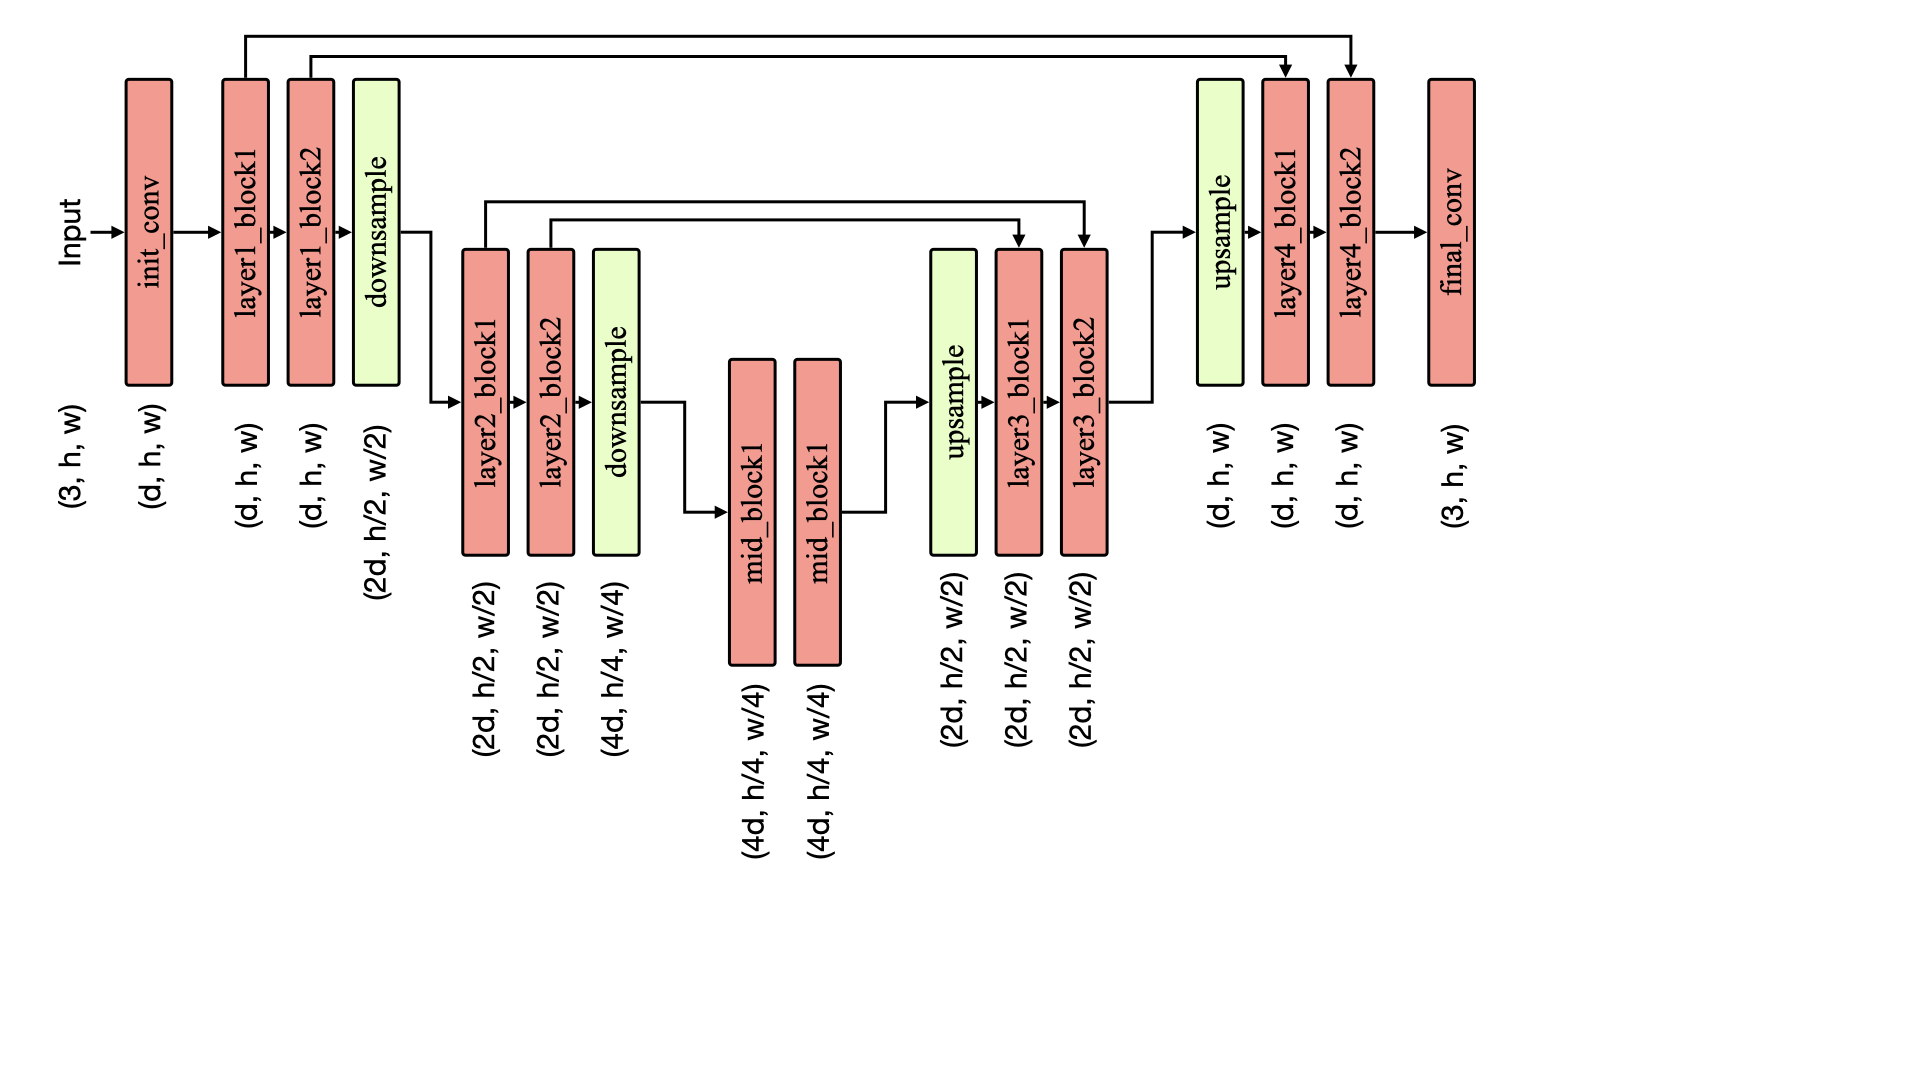

In [9]:
from IPython.display import Image
Image('unet.png')

在 `cs231n/unet.py` 中实现 `Unet.__init__` 方法，以定义 UNet 模型的上采样和下采样块，并在下方进行测试。如果您的实现正确，您应该不会看到任何错误。调用 `Unet(dim=d, condition_dim=condition_dim, dim_mults=(2,4))` 应该能成功创建一个与上图所示架构相对应的 UNet 模型。

In [10]:
from cs231n.unet import Unet, ResnetBlock, Downsample, Upsample

dim = 2
condition_dim = 4
dim_mults = (1, 2, 4)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)


# 检查层数
assert len(unet.downs) == len(dim_mults), "Number of Unet downsampling blocks is wrong."
assert len(unet.ups) == len(dim_mults), "Number of Unet upsampling blocks is wrong."


# 检查层
try:
  expected_downs_dims = [2, 2, 8, 2, 2, 8, 2, 2, 8, 2, 2, 8, 4, 4, 8, 4, 4, 8]
  downs_dims = [
      d for m in unet.downs for d in [
          m[0].dim, m[0].dim_out, m[0].context_dim, m[1].dim, m[1].dim_out, m[1].context_dim,
      ]
  ]
  assert downs_dims == expected_downs_dims, "Dimensions don't match"
except Exception as e:
  raise RuntimeError("Downsampling blocks wrongly configured") from e


try:
  expected_ups_dims = [8, 4, 8, 8, 4, 8, 4, 2, 8, 4, 2, 8, 4, 2, 8, 4, 2, 8]
  ups_dims = [
      d for m in unet.ups for d in [
          m[1].dim, m[1].dim_out, m[1].context_dim, m[2].dim, m[2].dim_out, m[2].context_dim,
      ]
  ]
  assert ups_dims == expected_ups_dims, "Dimensions don't match"
except Exception as e:
  raise RuntimeError("Upsampling blocks wrongly configured") from e

# 检查参数数量
num_params = sum(p.numel() for p in unet.parameters())
expected_num_params = 6499
assert num_params == expected_num_params, "Unet model creation is wrong!"


在 `cs231n/unet.py` 中填写 `Unet.forward` 方法并在下方进行测试。目前，请不必担心 `Unet.cfg_forward` 方法。您应该会看到相对误差小于 1e-6。

In [11]:
np.random.seed(231)
torch.manual_seed(231)

dim = 4
condition_dim = 4
dim_mults = (2, 4)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)
unet.eval()

b = 2
h = w = 4
inp_x = torch.randn(b, 3, h, w)
inp_text_emb = torch.randn(b, condition_dim)
inp_t = torch.tensor([8, 25]).long()
out = unet.forward(x=inp_x, time=inp_t,
                   model_kwargs={"text_emb": inp_text_emb}).detach().numpy()

expected_out = np.array(
      [[[[ 0.3530089,   0.49302575,  0.55152094,  0.20567769],
         [ 1.1295223,   0.05811183,  0.2143015,   0.23898259],
         [ 0.44839963,  1.0291728,   0.18519637,  0.21956968],
         [ 0.7035912,   0.716347,    0.9166326,  -0.11552593]],
        [[ 0.04585427, -0.26847702,  0.08526254,  0.2396591 ],
         [ 0.2858743,  -0.29726404,  0.02462834,  0.2350314 ],
         [ 0.3121434,   0.3962962,   0.65541625, -0.300183  ],
         [ 0.3409412,   0.35369393,  0.37445623,  0.10297439]],
        [[ 0.49440542,  0.72878885,  0.6669705,   0.56822944],
         [ 1.0084232,   0.19204213,  0.61240125,  0.575651  ],
         [ 0.6452671,   0.91168964,  0.6458106,   0.25952405],
         [ 0.7147298,   0.7707498,   0.88941365,  0.35422024]]],
       [[[ 0.3186316,  -0.17632714,  0.440247,    0.05124736],
         [ 0.6866561,   0.3019496,   0.18366373,  0.42941707],
         [-0.09776017,  0.55849403,  0.30689716,  0.12954405],
         [ 0.3667726,   0.740231,    0.43682802,  0.08275545]],
        [[-0.29714173, -0.28515863, -0.02289355,  0.05637485],
         [-0.10230345,  0.182563,    0.8107456,   0.18209176],
         [ 0.57062995,  0.07061654,  0.2864037,   0.17969263],
         [ 0.31491554,  0.5652035,   0.3810383,   0.05889529]],
        [[ 0.14559639,  0.36408228,  0.5657894,   0.24066216],
         [ 0.4431491,   0.38140664,  1.1457629,   0.40314198],
         [ 0.6673274,   0.5922724,   0.44549578,  0.5544277 ],
         [ 0.5405652,   0.88729244,  0.66340685,  0.23414826]]]])

print("forward error: ", rel_error(out, expected_out))

forward error:  1.4688642710356004e-05


# p_losses

现在我们的模型实现已经完成，让我们编写 DDPM 的去噪训练步骤。如前所述，优化去噪损失等同于最小化数据集的预期负对数似然。在 `cs231n/gaussian_diffusion.py` 中完成 `GaussianDiffusion.p_losses` 方法，并在下面进行测试。您应该会看到相对误差小于 1e-6。

In [12]:
np.random.seed(231)
torch.manual_seed(231)

dim = 4
condition_dim = 4
dim_mults = (2, 4)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)
unet.eval()

h = w = 4
b = 3
diffusion = GaussianDiffusion(
      model=unet,
      image_size=h,
      timesteps=1000,
      beta_schedule="sigmoid",
      objective="pred_x_start",
)

inp_x = torch.randn(b, 3, h, w)
inp_model_kwargs = {"text_emb": torch.randn(b, condition_dim)}
out = diffusion.p_losses(inp_x, inp_model_kwargs)
expected_out = 30.0160

print("forward error: ", rel_error(out.item(), expected_out))

forward error:  7.114425673382465e-07


## p_sample

现在只剩下最后一部分了。DDPM 通过迭代执行逆向过程来生成样本。这个逆向过程的每次迭代都涉及从 $p(x_{t-1}|x_t)$ 中采样。打开 `cs231n/gaussian_diffusion.py` 并按照论文中的公式 (6) 实现 `p_sample` 方法。该公式描述了以 $x_t$ 和 $x_0$ 为条件，从前向过程的后验中采样，其中 $x_0$ 可以从去噪模型的输出中推导出来。我们已经实现了 `sample` 方法，它会迭代调用 `p_sample` 来从输入文本生成图像。

在下面测试您的 `p_sample` 实现，您应该会看到相对误差小于 1e-6。

In [14]:
np.random.seed(231)
torch.manual_seed(231)

dim = 4
condition_dim = 4
dim_mults = (2,)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)
unet.eval()

h = w = 4
b = 1
inp_x_t = torch.randn(b, 3, h, w)
inp_model_kwargs = {"text_emb": torch.randn(b, condition_dim)}
t = 231

# 测试 1
diffusion = GaussianDiffusion(
      model=unet,
      image_size=h,
      timesteps=1000,
      beta_schedule="sigmoid",
      objective="pred_x_start",
)
out = diffusion.p_sample(inp_x_t, t, inp_model_kwargs).detach().numpy()

expected_out = np.array(
    [[[[ 1.1249855,   0.098786,   -0.674154,    1.3266845 ],
         [-0.21832949,  0.4874724,   1.0712924,  -0.7355726 ],
         [-0.19198017,  1.0347139,   0.03363481,  0.47500697],
         [-1.0178545,  -0.52259684, -0.11972852, -0.02105119]],
        [[ 0.06438226, -1.5796007,   0.43629852, -0.67392266],
         [-1.1564192,  -1.7009112,   0.878653,   -1.2563533 ],
         [-0.45194352,  1.0274173,   0.62859684, -0.49643248],
         [-0.18070872,  0.51325583, -0.74465716, -0.5262963 ]],
        [[ 0.76330817,  1.5878401,   1.9983996,   0.6618041 ],
         [ 0.16782297,  0.5638586,  -0.8150751,   1.9507835 ],
         [ 0.7401889,   1.2696184,   1.8468435,  -1.4796975 ],
         [ 0.6636643,  -0.83933365,  0.78857577,  0.13521622]]]])
print("forward error: ", rel_error(out, expected_out))

# 测试 2
diffusion = GaussianDiffusion(
      model=unet,
      image_size=h,
      timesteps=1000,
      beta_schedule="cosine",
      objective="pred_noise",
)
out = diffusion.p_sample(inp_x_t, t, inp_model_kwargs).detach().numpy()

expected_out = np.array(
    [[[[ 1.1139543,   0.11015256, -0.7337392,   1.3292073 ],
         [-0.286727,    0.48420003,  1.0737748,  -0.764173  ],
         [-0.22848499,  1.0443672,   0.07089197,  0.50183666],
         [-1.0453997,  -0.5474187,  -0.06630269, -0.11730157]],
        [[ 0.10919069, -1.5161378,   0.38542387, -0.6693473 ],
         [-1.0730051,  -1.6837747,   0.87086374, -1.2265388 ],
         [-0.48162907,  1.0328836,   0.6336425,  -0.47346604],
         [-0.11769794,  0.5335539,  -0.71324545, -0.47889465]],
        [[ 0.8311781,   1.6457081,   1.9775101,   0.563749  ],
         [ 0.25127694,  0.57862943, -0.8148284,   1.8744429 ],
         [ 0.75546896,  1.1215659,   1.9582558,  -1.535511  ],
         [ 0.62724066, -0.8814953,   0.77542645,  0.12667023]]]])
print("forward error: ", rel_error(out, expected_out))

forward error:  6.96344541990084e-08
forward error:  6.125410007962113e-08


## 训练 (Training)

我们已经拥有了 DDPM 训练所需的所有组件，现在可以在我们的 Emoji 数据集上训练模型。您无需在此处编写任何代码，但我们鼓励您查看 `cs231n/ddpm_trainer.py` 中的训练代码。

对于 notebook 的其余部分，我们将使用来自 `cs231n/exp/pretrained` 文件夹的预训练模型，该模型已经在这个数据集上训练了许多次迭代。不过，您也可以在 Colab GPU 上自由训练您自己的模型（确保更改 `results_folder`）。请注意，在开始看到合理的生成结果之前，T4 GPU 上可能需要超过 12 小时的时间。

In [16]:
from cs231n.ddpm_trainer import Trainer

dim = 48
image_size = 32
results_folder = "./cs231n/exp/pretrained"
condition_dim = 512

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = Unet(
    dim=dim,
    dim_mults=(1, 2, 4, 8),
    condition_dim=condition_dim,
)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

diffusion = GaussianDiffusion(
    model,
    image_size=image_size,
    timesteps=100,  # 扩散步数
    objective="pred_noise",  # "pred_x_start" 或 "pred_noise"
)

dataset = EmojiDataset(image_size)

trainer = Trainer(
    diffusion,
    dataset,
    device,
    train_batch_size=256,
    weight_decay=0.0,
    train_lr=1e-3,
    train_num_steps=50000,
    results_folder=results_folder,
)

# 您不需要自己训练它。
# trainer.train()


Number of parameters: 12444963
emoji_data.npz already downloaded.
text_embeddings.pt already downloaded.


In [17]:
# 相反，我们将加载一个预训练模型。
trainer.download_pretrained()
trainer.load(70000)

Downloading..../cs231n/exp/pretrained\model-70000.pt
Download complete.
loading model from ./cs231n/exp/pretrained\model-70000.pt.


In [18]:
# 辅助函数，在推理时获取 CLIP 文本嵌入。
from cs231n.emoji_dataset import ClipEmbed
clip_embedder = ClipEmbed(device)
def get_text_emb(text):
    return trainer.ds.embed_new_text(text, clip_embedder)

# 辅助函数，用于可视化生成的图像。
def show_images(img):
    # img: B x T x 3 x H x W
    plt.figure(figsize=(10, 10))
    img2 = img.clamp(0, 1).permute(0, 3, 1, 4, 2).flatten(0, 1).flatten(1, 2).cpu().numpy()
    plt.imshow(img2)
    plt.axis('off')

    plt.show()

100%|███████████████████████████████████████| 338M/338M [00:31<00:00, 11.3MiB/s]


## 采样 (Sampling)

运行下面的单元格以可视化基于文本提示生成的表情符号。您可以随意修改提示以探索不同的生成结果。由于我们的表情符号数据集相当小，不足以训练一个完全泛化的文本到图像模型。正因为如此，对于未见过的提示，生成的效果可能很差，或者可能不忠实于输入文本（对于见过的示例也可能发生这种情况，但不太常见）。

为了加快采样速度，您可以使用 GPU 运行时。如果您切换了运行时类型，请确保重新运行整个 notebook。

sampling loop time step:   0%|          | 0/100 [00:00<?, ?it/s]

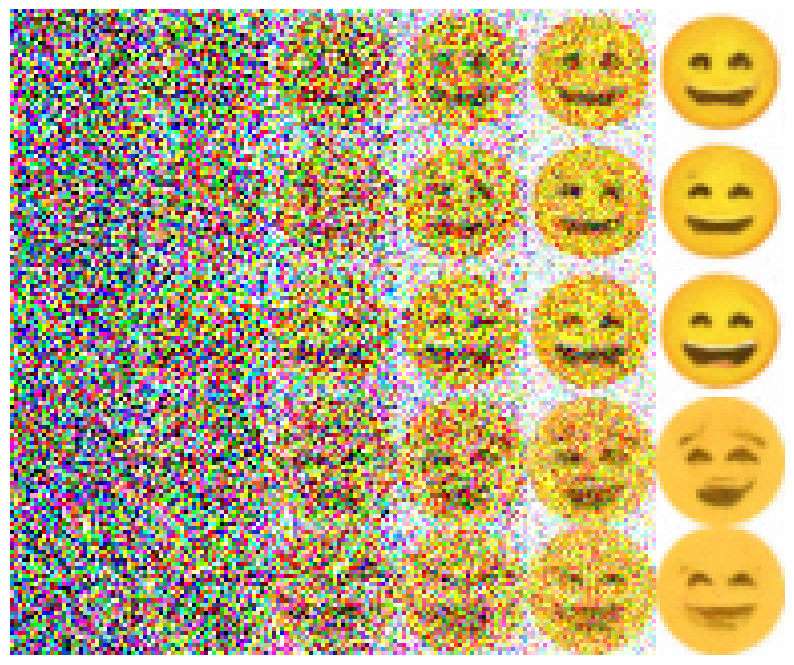

In [29]:
# text = "crying face"  # 见过的例子，生成效果好
text = "happy"  
text_emb = get_text_emb(text)
text_emb = text_emb[None].expand(5, -1).to(device)


img = trainer.diffusion_model.sample(
    batch_size=5,
    model_kwargs={"text_emb": text_emb},
    return_all_timesteps=True
)
show_images(img[:, ::20])

## 无分类器引导 (Classifier Free Guidance)

生成模型通常在保真度（即生成样本的质量或逼真度）和多样性（样本空间的可变性或覆盖范围）上进行评估。对于条件生成模型，保真度还指生成样本有多忠实于输入条件。这两个指标通常相互对立，导致它们之间需要权衡。Ho 等人引入了一种名为无分类器引导的简单技术 [3]，它允许对这种权衡进行显式控制。


在无分类器引导中，在条件扩散模型 $\epsilon_\theta(x_t, t, c)$ 的训练期间，条件 $c$ 会以一定的概率（通常为 0.1 到 0.2）被随机丢弃（即替换为 $c=\phi$）。在采样的每个去噪步骤中，预测将更新为：
$$\epsilon_\theta(x_t, t, c) \leftarrow (w+1) \epsilon_\theta(x_t, t, c) - w \epsilon_\theta(x_t, t, \phi)$$
其中 $w$ 是一个正标量（引导尺度）。换句话说，在每个去噪步骤中，我们执行两次预测，一次有条件，一次无条件，并将它们线性组合以倾向于条件生成。$w$ 是一个被调节用来优化特定模型评估指标的超参数。较高的 $w$ 会使得生成结果更忠实于条件，但往往会降低其多样性。

[3] Classifier-Free Diffusion Guidance. Jonathan Ho, Tim Salimans. [链接](https://arxiv.org/abs/2207.12598)

在 `cs231n/unet.py` 中实现 `Unet.cfg_forward` 方法中的无分类器引导，并在下方进行测试。您应该会看到相对误差小于 1e-6。

In [30]:
np.random.seed(231)
torch.manual_seed(231)

dim = 4
condition_dim = 4
dim_mults = (2, 4)
unet = Unet(dim=dim, condition_dim=condition_dim, dim_mults=dim_mults)
unet.eval()

b = 2
h = w = 4
inp_x = torch.randn(b, 3, h, w)
inp_text_emb = torch.randn(b, condition_dim)
inp_t = torch.tensor([8, 25]).long()
out = unet.forward(x=inp_x, time=inp_t,
                   model_kwargs={"text_emb": inp_text_emb, "cfg_scale": 2.31}
                   ).detach().numpy()
expected_out = np.array(
      [[[[ 0.3063889,   0.49175858,  0.53406465,  0.17793494],
         [ 1.0605793,   0.07291106,  0.26333052,  0.2807781 ],
         [ 0.47007525,  1.0033083,   0.15596265,  0.21308547],
         [ 0.6635294,   0.69716704,  0.7332697,  -0.14285703]],
        [[-0.14788617, -0.17531544,  0.06930217,  0.24703366],
         [ 0.2998472,  -0.25145096,  0.06968095,  0.28924388],
         [ 0.311122,    0.35599577,  0.6346719,  -0.30859607],
         [ 0.3706389,   0.33177835,  0.29829532,  0.11159261]],
        [[ 0.34566414,  0.79019654,  0.6489645,   0.5683719 ],
         [ 0.98117805,  0.176887,    0.6220584,   0.6494926 ],
         [ 0.66813314,  0.90341353,  0.65361,     0.21999073],
         [ 0.73401093,  0.75344837,  0.71971107,  0.32417077]]],
       [[[ 0.46322435, -1.3915588,   1.0951779,   0.37392217],
         [ 0.6877824,   0.14802843, -0.7159017,   0.22476494],
         [-0.28032526,  0.50201464,  0.0972808,   0.23250426],
         [ 0.38375473,  0.86657,     0.4424622,   0.2161349 ]],
        [[-0.34920466, -0.48507357,  0.06529156,  0.29454708],
         [-0.62153226,  0.0083245,   1.7356712,  -0.0690068 ],
         [ 0.7745638,  -0.11548355,  0.237822,    0.22680345],
         [ 0.06337905,  0.7001358,   0.36441565,  0.17163567]],
        [[ 0.16040441, -0.2551211,   0.8887521,   0.11380547],
         [-0.12803352,  0.2783994,   1.4620805,   0.19044566],
         [ 0.9112923,   0.75666,     0.3765695,   0.66629255],
         [ 0.3461262,   1.0881201,   0.6392708,   0.31749305]]]])


print("forward error: ", rel_error(out, expected_out))

Classifier-free guidance scale: 2.31
forward error:  0.0001179221661745567


运行下面的单元格以可视化使用无分类器引导生成的表情符号。您可以随意修改“cfg_scale”参数的值。如前所述，由于我们的模型泛化能力不强，因此即使使用较高的引导尺度，您也可能观察到，或可能观察不到忠实的生成结果。



sampling loop time step:   0%|          | 0/100 [00:00<?, ?it/s]

Classifier-free guidance scale: 1


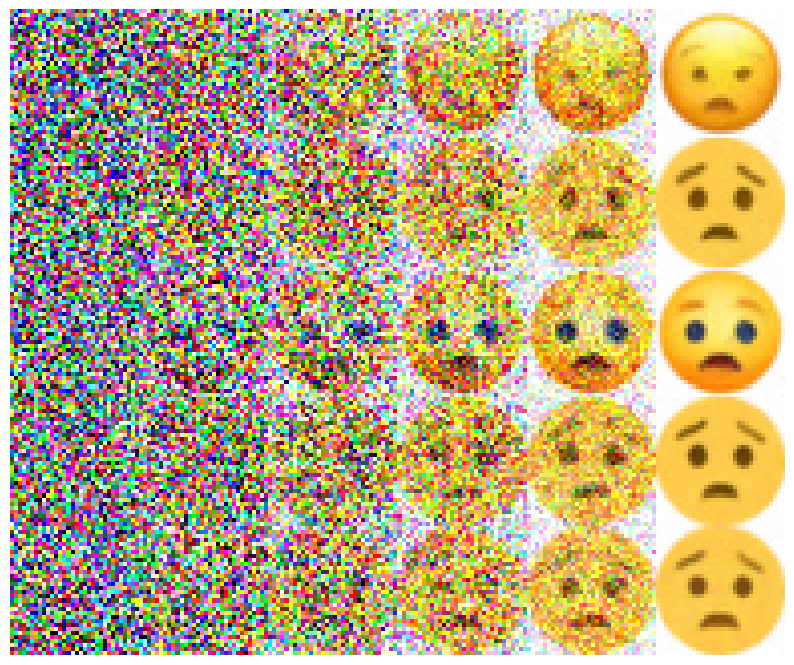

In [37]:
# text = "crying face"  # 见过的例子，生成效果好
text = "crying face"  # 见过的例子，生成效果好
# text = "crying face with cowboy hat"  # 未见过的例子，生成效果差
text_emb = get_text_emb(text)
text_emb = text_emb[None].expand(5, -1).to(device)


img = trainer.diffusion_model.sample(
    batch_size=5,
    model_kwargs={"text_emb": text_emb, "cfg_scale": 1},
    return_all_timesteps=True
)
show_images(img[:, ::20])